<a href="https://colab.research.google.com/github/Shyamanth-001/CropPricePrediction/blob/main/CropPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [ ]:
from yellowbrick.model_selection import validation_curve

In [ ]:
df = pd.read_csv("raw_crop_dataset.csv")
df.head()

,Year,Crop,Planted_Area,Harvested_Area,Average_Yield,Temp_min,Temp_max,Temp_mean,Precipitation,Production
0,2000,Wheat,2498.160475,2342.471559,3.927976,19.505114,24.441153,21.973170,64.520903,9201.171518
1,2000,Barley,4464.704583,3796.243445,3.832290,5.501960,14.909018,10.411690,103.084778,14548.306974
2,2000,Chickpea,1727.299869,1288.308555,2.216969,17.199294,23.368816,20.495129,202.963224,2856.140092
3,2000,Lentil,1557.975443,1204.371357,2.465447,14.765872,21.720421,19.121400,178.558610,2969.314198
4,2000,Vetch,3369.658275,2397.891297,3.430179,11.215328,18.257139,13.410482,291.408008,8225.197349


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            115 non-null    int64  
 1   Crop            115 non-null    object 
 2   Planted_Area    115 non-null    float64
 3   Harvested_Area  115 non-null    float64
 4   Average_Yield   115 non-null    float64
 5   Temp_min        115 non-null    float64
 6   Temp_max        115 non-null    float64
 7   Temp_mean       115 non-null    float64
 8   Precipitation   115 non-null    float64
 9   Production      115 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 9.1+ KB


In [ ]:
df.describe()

,Year,Planted_Area,Harvested_Area,Average_Yield,Temp_min,Temp_max,Temp_mean,Precipitation,Production
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,2011.000000,3097.187178,2539.791398,3.121559,16.093567,22.982069,19.594528,174.596534,7904.205412
std,6.662279,1186.299087,991.332591,1.155877,6.062912,6.098338,6.162220,72.886850,4227.539808
min,2000.000000,1072.887303,776.352775,1.022088,5.501960,12.425878,10.287870,53.864154,901.574063
25%,2005.000000,1969.760472,1569.548038,2.165777,10.472959,16.981450,13.574546,116.378410,4855.961600
50%,2011.000000,3194.935157,2665.804800,3.279559,16.327561,23.368816,20.214946,170.285025,7321.499106
75%,2017.000000,4053.575287,3390.878163,4.076961,21.254561,28.580130,25.108426,240.581066,10952.628160
max,2022.000000,4986.547348,4319.747071,4.960215,27.311456,33.493141,29.730305,299.929418,18511.789021


In [ ]:
#Checking for null values
df.isna().sum()

,0
Year,0
Crop,0
Planted_Area,0
Harvested_Area,0
Average_Yield,0
Temp_min,0
Temp_max,0
Temp_mean,0
Precipitation,0
Production,0


In [ ]:
#Checking for duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Year', 'Crop', 'Planted_Area', 'Harvested_Area', 'Average_Yield',
       'Temp_min', 'Temp_max', 'Temp_mean', 'Precipitation', 'Production'],
      dtype='object')

In [ ]:
# Checking for Zero-Variance columns
zero_var = []
for col in df.columns:
  if df[col].var==0:
    zero_var.append(col)
zero_var

[]

In [ ]:
# Checking for categorial columns
categorial_cols = []
for col in df.columns:
  if df[col].dtype=='object':
    categorial_cols.append(col)
categorial_cols

['Crop']

<Axes: xlabel='Crop', ylabel='Production'>

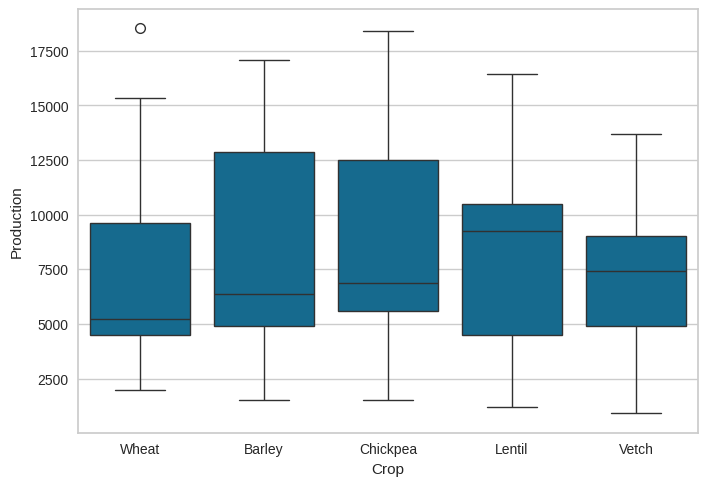

In [ ]:
sns.boxplot(x='Crop', y='Production', data=df)

In [ ]:
df1 = pd.get_dummies(df,columns=categorial_cols)
df1.head()

,Year,Planted_Area,Harvested_Area,Average_Yield,Temp_min,Temp_max,Temp_mean,Precipitation,Production,Crop_Barley,Crop_Chickpea,Crop_Lentil,Crop_Vetch,Crop_Wheat
0,2000,2498.160475,2342.471559,3.927976,19.505114,24.441153,21.973170,64.520903,9201.171518,False,False,False,False,True
1,2000,4464.704583,3796.243445,3.832290,5.501960,14.909018,10.411690,103.084778,14548.306974,True,False,False,False,False
2,2000,1727.299869,1288.308555,2.216969,17.199294,23.368816,20.495129,202.963224,2856.140092,False,True,False,False,False
3,2000,1557.975443,1204.371357,2.465447,14.765872,21.720421,19.121400,178.558610,2969.314198,False,False,True,False,False
4,2000,3369.658275,2397.891297,3.430179,11.215328,18.257139,13.410482,291.408008,8225.197349,False,False,False,True,False


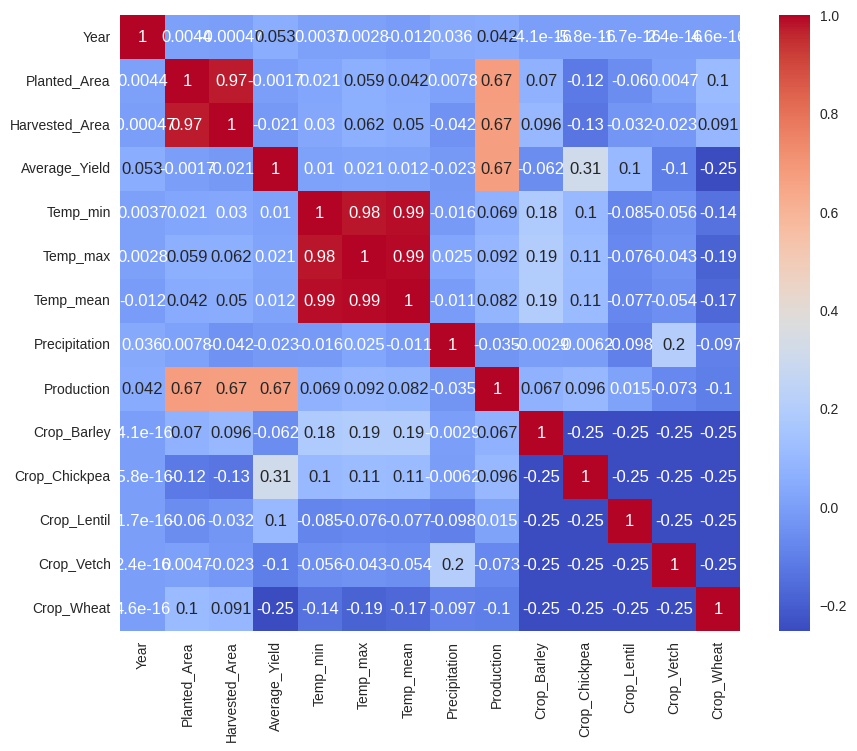

In [ ]:
corr = df1.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [ ]:
corr

,Year,Planted_Area,Harvested_Area,Average_Yield,Temp_min,Temp_max,Temp_mean,Precipitation,Production,Crop_Barley,Crop_Chickpea,Crop_Lentil,Crop_Vetch,Crop_Wheat
Year,1.000000e+00,0.004444,-0.000470,0.052744,0.003701,0.002754,-0.011734,0.036075,0.042193,-4.147925e-16,-5.763433e-16,-1.702832e-16,2.445093e-16,4.628211e-16
Planted_Area,4.444440e-03,1.000000,0.972937,-0.001714,0.021293,0.058574,0.041597,0.007804,0.672415,7.039417e-02,-1.197961e-01,-6.020948e-02,4.676017e-03,1.049354e-01
Harvested_Area,-4.700808e-04,0.972937,1.000000,-0.021044,0.030487,0.062468,0.049736,-0.041598,0.670185,9.627152e-02,-1.325178e-01,-3.154363e-02,-2.333711e-02,9.112703e-02
Average_Yield,5.274417e-02,-0.001714,-0.021044,1.000000,0.010070,0.020882,0.011710,-0.022620,0.670724,-6.193478e-02,3.129413e-01,1.041496e-01,-1.021676e-01,-2.529885e-01
Temp_min,3.701141e-03,0.021293,0.030487,0.010070,1.000000,0.979289,0.989960,-0.016169,0.069472,1.844168e-01,9.952465e-02,-8.454456e-02,-5.611215e-02,-1.432848e-01
Temp_max,2.754269e-03,0.058574,0.062468,0.020882,0.979289,1.000000,0.990440,0.024741,0.091577,1.936512e-01,1.140777e-01,-7.648825e-02,-4.254225e-02,-1.886984e-01
Temp_mean,-1.173374e-02,0.041597,0.049736,0.011710,0.989960,0.990440,1.000000,-0.010841,0.081803,1.945747e-01,1.088777e-01,-7.725781e-02,-5.431031e-02,-1.718842e-01
Precipitation,3.607536e-02,0.007804,-0.041598,-0.022620,-0.016169,0.024741,-0.010841,1.000000,-0.035024,-2.922025e-03,-6.169425e-03,-9.837801e-02,2.045998e-01,-9.713030e-02
Production,4.219336e-02,0.672415,0.670185,0.670724,0.069472,0.091577,0.081803,-0.035024,1.000000,6.686641e-02,9.598864e-02,1.492691e-02,-7.328322e-02,-1.044987e-01
Crop_Barley,-4.147925e-16,0.070394,0.096272,-0.061935,0.184417,0.193651,0.194575,-0.002922,0.066866,1.000000e+00,-2.500000e-01,-2.500000e-01,-2.500000e-01,-2.500000e-01


In [ ]:
corr['Production']

,Production
Year,0.042193
Planted_Area,0.672415
Harvested_Area,0.670185
Average_Yield,0.670724
Temp_min,0.069472
Temp_max,0.091577
Temp_mean,0.081803
Precipitation,-0.035024
Production,1.000000
Crop_Barley,0.066866


<Axes: xlabel='Year', ylabel='Production'>

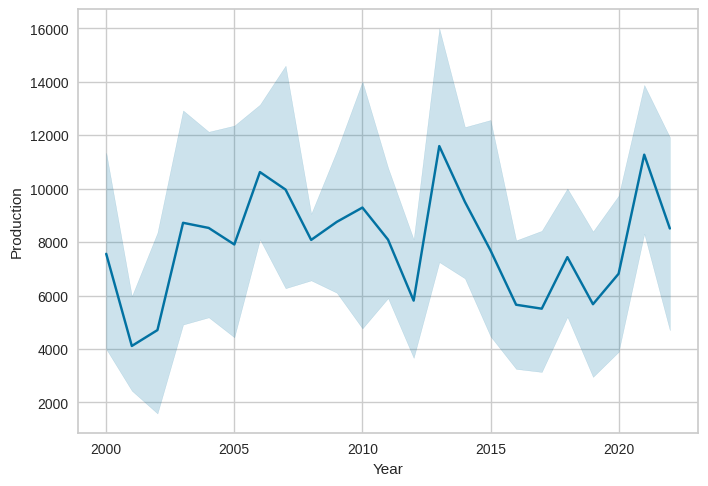

In [ ]:
sns.lineplot(x='Year', y='Production', data=df)

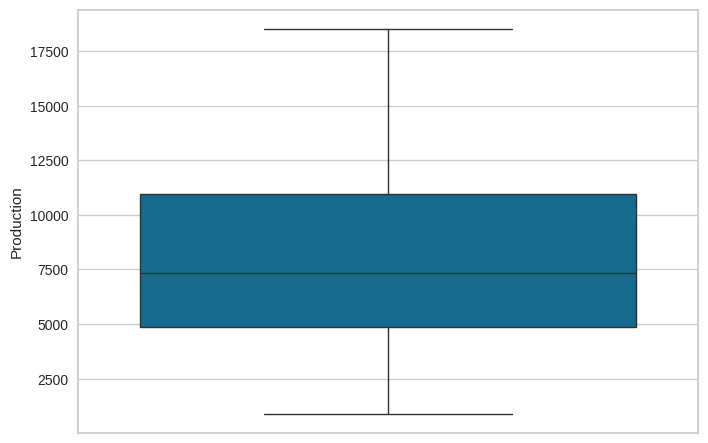

In [ ]:
# To check for outliers
sns.boxplot(df['Production'])
plt.show()

In [ ]:
# Outliers are removed using IQR
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Production'] >= Q1 - 1.5*IQR) &
        (df['Production'] <= Q3 + 1.5*IQR)]

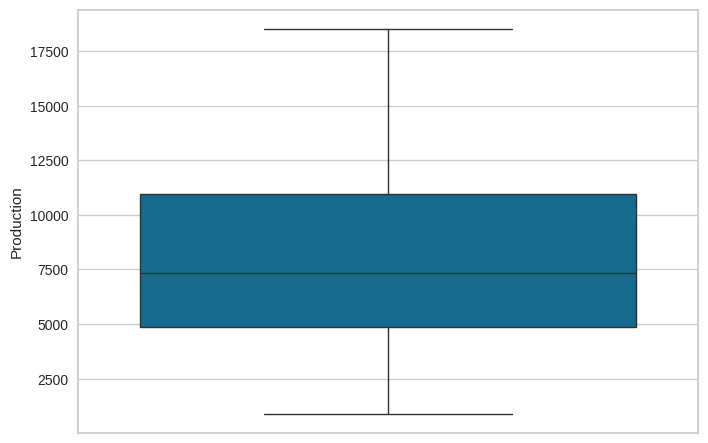

In [ ]:
sns.boxplot(df['Production'])
plt.show()

<Axes: xlabel='Production', ylabel='Count'>

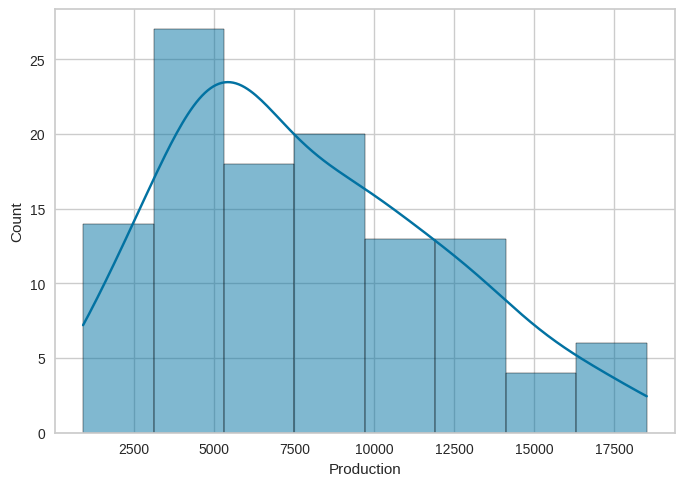

In [ ]:
sns.histplot(df['Production'],kde=True)

<Axes: xlabel='Harvested_Area', ylabel='Production'>

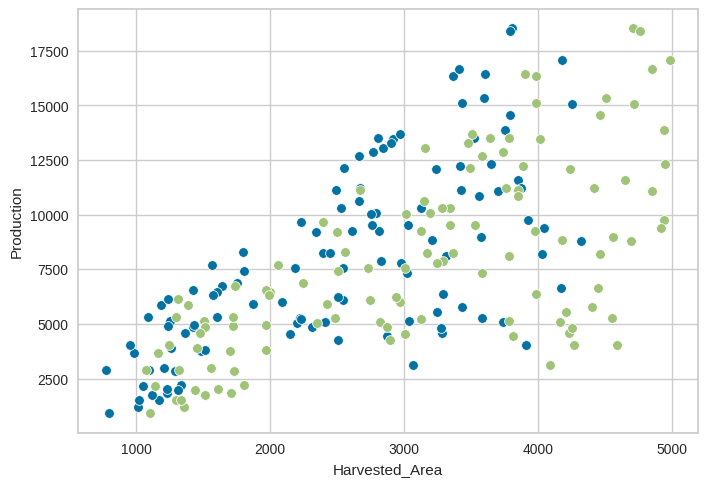

In [ ]:
sns.scatterplot(x='Harvested_Area', y='Production', data=df)
sns.scatterplot(x='Planted_Area', y='Production', data=df)

In [ ]:
# Splitting features and target
X = df1.drop('Production',axis=1)
y = df1['Production']

Multi-LinearRegression

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# because of large variations in values features need to be scaled
std_scale_cols = ['Planted_Area', 'Harvested_Area', 'Average_Yield',
                  'Temp_min', 'Temp_max', 'Temp_mean', 'Precipitation']
scaler = StandardScaler()
X_train[std_scale_cols] = scaler.fit_transform(X_train[std_scale_cols])
X_test[std_scale_cols] = scaler.transform(X_test[std_scale_cols])

In [ ]:
#target (Production) has large values so it needs to be log transformed
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)


In [ ]:
multi_lr = LinearRegression()
multi_lr.fit(X_train,y_train)

y_pred = multi_lr.predict(X_test)

r2 = r2_score(y_test,y_pred)
print(f"R2-score :",r2)

R2-score : 0.9442363453775722


Regularization

In [ ]:
lasso_reg = Lasso(alpha=10.0)
lasso_reg.fit(X_train,y_train)


Lasso(alpha=10.0)

In [ ]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train,y_train)

Ridge(alpha=1)

In [ ]:
elastic_reg = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic_reg.fit(X_train, y_train)

ElasticNet()

In [ ]:
y_pred_lr = multi_lr.predict(X_test)
y_pred_lasso = lasso_reg.predict(X_test)
y_pred_ridge = ridge_reg.predict(X_test)
y_pred_elastic = elastic_reg.predict(X_test)

print("R2_score lr:",r2_score(y_pred_lr,y_test))
print("R2_score lasso:",r2_score(y_pred_lasso,y_test))
print("R2_score ridge:",r2_score(y_pred_ridge,y_test))
print("R2_score elastic:",r2_score(y_pred_elastic,y_test))

R2_score lr: 0.9402968069330567
R2_score lasso: -1.2110349223204013e+29
R2_score ridge: 0.9388508116236685
R2_score elastic: -1.2110349223204013e+29


Polynomial Regression

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

In [ ]:
linear_reg = LinearRegression()
linear_reg.fit(X_train_poly,y_train)

y_pred = linear_reg.predict(X_test_poly)

print("R2_score : ",r2_score(y_test,y_pred))
print("Mean-Squared-Error : ",mean_squared_error(y_test,y_pred))

R2_score :  0.9999999999991985
Mean-Squared-Error :  1.3698573011110518e-05


Random Forest Regression

In [ ]:
X_train_rf,X_test_rf,y_train_rf,y_test_rf = train_test_split(X,y,test_size=0.2,random_state=0)


In [ ]:
rfr = RandomForestRegressor(random_state=2)
rfr.fit(X_train_rf,y_train_rf)

y_pred_rf = rfr.predict(X_test)

r2_rf = r2_score(y_pred_rf,y_test_rf)

In [ ]:
r2_rf

0.9233791271622298

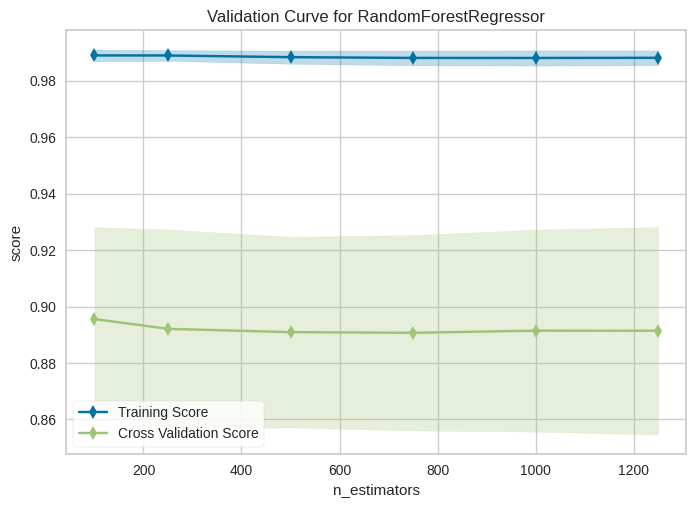

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestRegressor'}, xlabel='n_estimators', ylabel='score'>,
                cv=3, estimator=RandomForestRegressor(random_state=2),
                param_name='n_estimators',
                param_range=array([ 100,  250,  500,  750, 1000, 1250]),
                scoring='r2')

In [ ]:
est= [100,250,500,750,1000,1250]
vc1 = validation_curve(RandomForestRegressor(random_state=2),X=X_train_rf, y=y_train_rf, param_name='n_estimators', param_range=est, scoring='r2', cv=3)
vc1

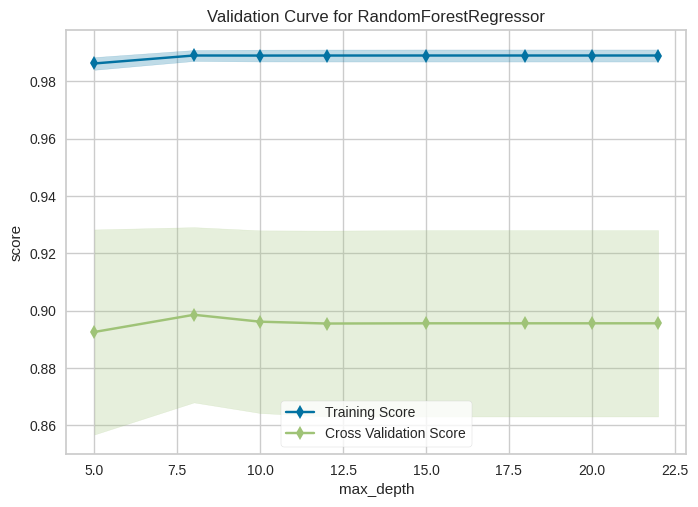

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestRegressor'}, xlabel='max_depth', ylabel='score'>,
                cv=3, estimator=RandomForestRegressor(random_state=2),
                param_name='max_depth',
                param_range=array([ 5,  8, 10, 12, 15, 18, 20, 22]),
                scoring='r2')

In [ ]:
depth= [5,8,10,12,15,18,20,22]
vc2 = validation_curve(RandomForestRegressor(random_state=2),X=X_train_rf, y=y_train_rf, param_name='max_depth', param_range=depth, scoring='r2', cv=3)
vc2

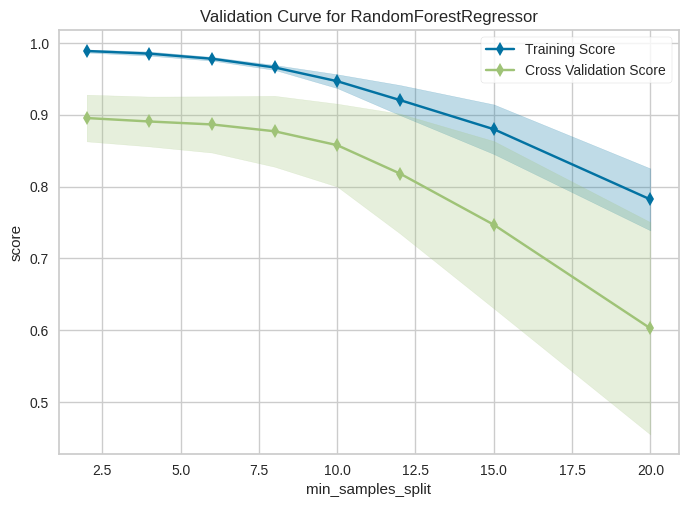

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestRegressor'}, xlabel='min_samples_split', ylabel='score'>,
                cv=3, estimator=RandomForestRegressor(random_state=2),
                param_name='min_samples_split',
                param_range=array([ 2,  4,  6,  8, 10, 12, 15, 20]),
                scoring='r2')

In [ ]:
min_samples = [2,4,6,8,10,12,15,20]
vc3 = validation_curve(RandomForestRegressor(random_state=2), X=X_train_rf, y=y_train_rf, param_name='min_samples_split', param_range=min_samples, scoring='r2', cv=3)
vc3


In [ ]:
rfr_f = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=2, random_state=2)
rfr_f.fit(X_train_rf,y_train_rf)

y_pred_rf_f = rfr_f.predict(X_test_rf)
r2_f = r2_score(y_pred_rf_f,y_test_rf)


In [ ]:
r2_f

0.919688069286177